In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("olx_massive_real_estate.xlsx")

In [3]:
df.head()

,id,title,description,url,created_time,last_refresh_time,valid_to_time,pushup_time,category_id,category_name,...,wc,furnished,more,repairs,comission,price,layout,near_is,ceiling_height,kitchen_area
0,64741454,Учтепа 14 кварталда афруз,Продается 3х комнатная квартира своя . Учтепин...,https://www.olx.uz/d/obyavlenie/uchtepa-14-kva...,2026-05-22T17:10:38+05:00,2026-05-22T17:12:58+05:00,2026-06-21T17:10:39+05:00,NaN,13,NaN,...,Раздельный,Нет,"Телефон, Кухня, Балкон",Средний,Нет,900 097 500 сум,NaN,NaN,NaN,NaN
1,64739923,"Продается 1-комн. квартира, ЖК SOY BOYI - Mura...","Своя квартира 1/9/15 евродвушка, без маклера<b...",https://www.olx.uz/d/obyavlenie/prodaetsya-1-k...,2026-05-22T15:13:17+05:00,2026-05-22T15:21:26+05:00,2026-06-21T15:13:18+05:00,NaN,13,NaN,...,Совмещенный,Нет,"Кухня, Балкон",NaN,Нет,660 000 000 сум,Раздельная,"Больница, поликлиника, Детская площадка, Детск...",NaN,NaN
2,64114841,Продается своя квартира Чиланзар-30 (Алгоритм)...,Своя квартира с качественным ремонтом.<br />\n...,https://www.olx.uz/d/obyavlenie/prodaetsya-svo...,2026-04-02T11:47:07+05:00,2026-05-21T20:01:03+05:00,2026-06-02T14:20:45+05:00,2026-05-21T20:01:03+05:00,13,NaN,...,Совмещенный,Да,"Интернет, Телефон, Холодильник, Телевизор, Каб...",NaN,Нет,789 685 540 сум,Раздельная,NaN,NaN,NaN
3,63854549,Продаётся 4xКомнатная квартира на Чиланзар 23к...,Продаётся квартира на чиланзаре 23 квартала на...,https://www.olx.uz/d/obyavlenie/prodaetsya-4xk...,2026-03-13T10:32:33+05:00,2026-05-22T22:03:41+05:00,2026-06-24T20:23:44+05:00,2026-03-20T22:40:27+05:00,13,NaN,...,Раздельный,Нет,"Балкон, Кондиционер, Кухня, Интернет",Евроремонт,Нет,1 500 162 500 сум,Раздельная,"Парк, зелёная зона, Детская площадка, Ресторан...",280,NaN
4,64660473,ЖК Soy Bo'yi(Murad Building's) 4-комнатная ква...,Учтепинский район <br />\nКвартира 4/4/15<br ...,https://www.olx.uz/d/obyavlenie/zhk-soy-boyimu...,2026-05-15T21:56:07+05:00,2026-05-22T21:56:11+05:00,2026-06-14T21:56:08+05:00,2026-05-22T21:56:11+05:00,13,NaN,...,2 санузла и более,Нет,NaN,Черновая отделка,Нет,1 536 166 400 сум,Раздельная,NaN,320,NaN


In [4]:
df.columns

Index(['id', 'title', 'description', 'url', 'created_time',
       'last_refresh_time', 'valid_to_time', 'pushup_time', 'category_id',
       'category_name', 'region', 'district', 'latitude', 'longitude',
       'seller_id', 'seller_name', 'photos_count', 'status', 'type_of_market',
       'number_of_rooms', 'total_living_area', 'total_area', 'floor',
       'total_floors', 'house_type', 'year_of_construction_sale', 'wc',
       'furnished', 'more', 'repairs', 'comission', 'price', 'layout',
       'near_is', 'ceiling_height', 'kitchen_area'],
      dtype='object')

In [5]:
df_clean = df.copy()

In [6]:
df_clean.shape

(45638, 36)

In [7]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45638 entries, 0 to 45637
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         45638 non-null  int64  
 1   title                      45638 non-null  object 
 2   description                45638 non-null  object 
 3   url                        45638 non-null  object 
 4   created_time               45638 non-null  object 
 5   last_refresh_time          45638 non-null  object 
 6   valid_to_time              45638 non-null  object 
 7   pushup_time                28529 non-null  object 
 8   category_id                45638 non-null  int64  
 9   category_name              0 non-null      float64
 10  region                     45638 non-null  object 
 11  district                   42771 non-null  object 
 12  latitude                   0 non-null      float64
 13  longitude                  0 non-null      flo

In [8]:
df_clean.describe()

,id,category_id,category_name,latitude,longitude,seller_id,photos_count,number_of_rooms,floor,total_floors
count,4.563800e+04,45638.0,0.0,0.0,0.0,4.563800e+04,45638.000000,45638.000000,45635.000000,45638.000000
mean,6.283158e+07,13.0,NaN,NaN,NaN,2.057962e+08,7.323174,2.623800,5.169081,8.757592
std,4.003770e+06,0.0,NaN,NaN,NaN,2.080469e+08,2.612051,3.501642,4.309674,6.752326
min,2.940928e+06,13.0,NaN,NaN,NaN,2.910000e+02,1.000000,1.000000,1.000000,1.000000
25%,6.349644e+07,13.0,NaN,NaN,NaN,2.242913e+07,6.000000,2.000000,2.000000,4.000000
50%,6.444164e+07,13.0,NaN,NaN,NaN,1.125819e+08,8.000000,2.000000,4.000000,8.000000
75%,6.460302e+07,13.0,NaN,NaN,NaN,4.462545e+08,9.000000,3.000000,7.000000,10.000000
max,6.474620e+07,13.0,NaN,NaN,NaN,5.392643e+08,12.000000,450.000000,67.000000,56.000000


In [9]:
df_clean.dtypes

id                             int64
title                         object
description                   object
url                           object
created_time                  object
last_refresh_time             object
valid_to_time                 object
pushup_time                   object
category_id                    int64
category_name                float64
region                        object
district                      object
latitude                     float64
longitude                    float64
seller_id                      int64
seller_name                   object
photos_count                   int64
status                        object
type_of_market                object
number_of_rooms                int64
total_living_area             object
total_area                    object
floor                        float64
total_floors                   int64
house_type                    object
year_of_construction_sale     object
wc                            object
f

In [10]:
df_clean.columns

Index(['id', 'title', 'description', 'url', 'created_time',
       'last_refresh_time', 'valid_to_time', 'pushup_time', 'category_id',
       'category_name', 'region', 'district', 'latitude', 'longitude',
       'seller_id', 'seller_name', 'photos_count', 'status', 'type_of_market',
       'number_of_rooms', 'total_living_area', 'total_area', 'floor',
       'total_floors', 'house_type', 'year_of_construction_sale', 'wc',
       'furnished', 'more', 'repairs', 'comission', 'price', 'layout',
       'near_is', 'ceiling_height', 'kitchen_area'],
      dtype='object')

In [11]:
drop_cols = [
    "id",
    "title",
    "description",
    "url",
    "created_time",
    "last_refresh_time",
    "valid_to_time",
    "pushup_time",
    "category_id",
    "category_name",
    'latitude',
    'longitude',
    "seller_id",
    "seller_name",
    'photos_count',
    'wc',
    'layout',
    'comission',
    'repairs',
    'more',
    'furnished',
    'near_is',
    "status"
]
df_clean = df.drop(columns=drop_cols)

In [12]:
df_clean.columns

Index(['region', 'district', 'type_of_market', 'number_of_rooms',
       'total_living_area', 'total_area', 'floor', 'total_floors',
       'house_type', 'year_of_construction_sale', 'price', 'ceiling_height',
       'kitchen_area'],
      dtype='object')

In [13]:
df_clean['district'].value_counts()

district
Мирзо-Улугбекский район    7037
Юнусабадский район         5893
Яшнабадский район          5438
Яккасарайский район        5179
Мирабадский район          4597
Чиланзарский район         4092
Шайхантахурский район      3507
Сергелийский район         3380
Алмазарский район          2296
Учтепинский район           840
Бектемирский район          512
Name: count, dtype: int64

In [14]:
print("Ustunlardagi bo'sh joylar soni:")
print(df_clean.isna().sum())

Ustunlardagi bo'sh joylar soni:
region                           0
district                      2867
type_of_market                   0
number_of_rooms                  0
total_living_area            32937
total_area                       0
floor                            3
total_floors                     0
house_type                   11601
year_of_construction_sale    33223
price                            0
ceiling_height               31367
kitchen_area                 36749
dtype: int64


In [15]:
print(df_clean['region'].unique())

['Ташкентская область' 'Ферганская область' 'Кашкадарьинская область'
 'Бухарская область']


In [16]:
df_clean = df_clean[df_clean['region'] == 'Ташкентская область']

In [17]:
df_clean = df_clean[df_clean['type_of_market'] != 'От застройщика']

In [18]:
df_clean['district'] = df_clean['district'].fillna(df_clean['district'].mode()[0])

In [19]:
print(df_clean.isna().sum())

region                           0
district                         0
type_of_market                   0
number_of_rooms                  0
total_living_area            31436
total_area                       0
floor                            2
total_floors                     0
house_type                   11380
year_of_construction_sale    31629
price                            0
ceiling_height               29970
kitchen_area                 34937
dtype: int64


In [20]:
df_clean['floor'].describe()
df_clean['floor'].value_counts().sort_index()

floor
1.0     4822
2.0     5887
3.0     6501
4.0     6552
5.0     4064
6.0     2532
7.0     2760
8.0     2787
9.0     2301
10.0    1264
11.0     620
12.0     671
13.0     341
14.0     336
15.0     245
16.0     164
17.0     125
18.0     110
19.0      38
20.0      55
21.0      50
22.0      81
23.0      75
24.0      48
25.0      38
26.0      23
27.0      34
28.0       1
29.0       2
30.0      21
31.0      34
32.0      31
33.0      13
34.0      34
35.0      24
36.0       4
37.0      10
38.0      10
39.0      11
40.0      18
41.0       1
42.0       8
43.0       5
44.0       6
45.0       8
48.0       1
58.0       1
61.0       1
63.0       1
67.0       1
Name: count, dtype: int64

In [21]:
Q1 = df_clean['floor'].quantile(0.25)
Q3 = df_clean['floor'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['floor'] < lower) | (df_clean['floor'] > upper)]
len(outliers)

1332

In [22]:
df_clean['floor'].unique()

array([ 2., 14.,  3.,  1.,  4.,  5.,  9.,  7.,  6., 10., 11.,  8., 16.,
       12., 13., 15., 17., 22., nan, 42., 18., 31., 24., 23., 19., 20.,
       21., 25., 33., 30., 67., 35., 38., 39., 37., 41., 45., 48., 40.,
       26., 32., 44., 29., 34., 43., 63., 27., 36., 28., 58., 61.])

In [23]:
df_clean['floor'] = df_clean['floor'].clip(1, 52)

In [24]:
df_clean['floor'] = df_clean['floor'].fillna(df_clean['floor'].median())

In [25]:
df_clean['floor'] = df_clean['floor'].astype(int)

In [26]:
(df_clean['number_of_rooms'] > 12).sum()

22

In [27]:
df_clean[df_clean['number_of_rooms'] > 12]['number_of_rooms'].value_counts().sort_index()

number_of_rooms
15     2
22     2
25     1
37     1
45     1
47     1
60     1
64     1
65     1
80     1
82     2
86     1
98     1
100    1
105    1
123    1
133    1
255    1
450    1
Name: count, dtype: int64

In [28]:
df_clean[df_clean['number_of_rooms'] > 12]['number_of_rooms'].value_counts()

number_of_rooms
22     2
82     2
15     2
86     1
133    1
64     1
65     1
25     1
100    1
47     1
60     1
123    1
45     1
98     1
450    1
105    1
37     1
255    1
80     1
Name: count, dtype: int64

In [29]:
Q1 = df_clean['number_of_rooms'].quantile(0.25)
Q3 = df_clean['number_of_rooms'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['number_of_rooms'] < lower) | (df_clean['number_of_rooms'] > upper)]

len(outliers)

1818

In [30]:
df_clean['number_of_rooms'] = df_clean['number_of_rooms'].clip(1, 12)

In [31]:
df_clean.dtypes

region                       object
district                     object
type_of_market               object
number_of_rooms               int64
total_living_area            object
total_area                   object
floor                         int32
total_floors                  int64
house_type                   object
year_of_construction_sale    object
price                        object
ceiling_height               object
kitchen_area                 object
dtype: object

In [32]:
print(df_clean.isna().sum())

region                           0
district                         0
type_of_market                   0
number_of_rooms                  0
total_living_area            31436
total_area                       0
floor                            0
total_floors                     0
house_type                   11380
year_of_construction_sale    31629
price                            0
ceiling_height               29970
kitchen_area                 34937
dtype: int64


In [33]:
df_clean['total_living_area'].unique()

array(['63 м²', nan, '36 м²', ..., '181 м²', '63.30 м²', '96.60 м²'],
      dtype=object)

In [34]:
df_clean['total_living_area'] = df_clean['total_living_area'].str.replace('м²', '', regex=False)

In [35]:
df_clean['total_living_area'] = pd.to_numeric(df_clean['total_living_area'], errors='coerce')

In [36]:
df_clean['total_living_area'].isnull().sum()

31464

In [37]:
df_clean['total_living_area'] = df_clean['total_living_area'].fillna(
    df_clean.groupby('district')['total_living_area'].transform('median')
)

In [38]:
df_clean['total_living_area'].value_counts()

total_living_area
48.00    7060
50.00    6059
55.90    4553
67.81    4295
63.75    3823
         ... 
16.65       1
52.14       1
58.90       1
33.57       1
96.60       1
Name: count, Length: 1005, dtype: int64

In [39]:
df_clean.dtypes

region                        object
district                      object
type_of_market                object
number_of_rooms                int64
total_living_area            float64
total_area                    object
floor                          int32
total_floors                   int64
house_type                    object
year_of_construction_sale     object
price                         object
ceiling_height                object
kitchen_area                  object
dtype: object

In [40]:
df_clean.isnull().sum()

region                           0
district                         0
type_of_market                   0
number_of_rooms                  0
total_living_area                0
total_area                       0
floor                            0
total_floors                     0
house_type                   11380
year_of_construction_sale    31629
price                            0
ceiling_height               29970
kitchen_area                 34937
dtype: int64

In [41]:
df_clean['house_type'].unique()

array(['Панельный', 'Монолитный', nan, 'Кирпичный', 'Блочный',
       'Деревянный'], dtype=object)

In [42]:
df_clean['house_type'] = df_clean['house_type'].fillna(
    df_clean.groupby('district')['house_type']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x.mode())
)

In [43]:
df_clean['year_of_construction_sale'].value_counts()

year_of_construction_sale
1980 - 1989    2718
2025           1889
1990 - 2000    1339
1960 - 1979    1149
2024            874
2023            832
2022            475
2020            373
2021            303
2018            283
2019            264
2001 - 2010     225
2017            121
старше 1960      94
2011 - 2014      93
2016             65
2015             46
Name: count, dtype: int64

In [44]:
df_clean['year_of_construction_sale'].isnull().mean() * 100
73.94790984756384

73.94790984756384

In [45]:
df_clean = df_clean.drop(columns=['year_of_construction_sale'])

In [46]:
df_clean.isnull().sum()

region                   0
district                 0
type_of_market           0
number_of_rooms          0
total_living_area        0
total_area               0
floor                    0
total_floors             0
house_type               0
price                    0
ceiling_height       29970
kitchen_area         34937
dtype: int64

In [47]:
df_clean.dtypes

region                object
district              object
type_of_market        object
number_of_rooms        int64
total_living_area    float64
total_area            object
floor                  int32
total_floors           int64
house_type            object
price                 object
ceiling_height        object
kitchen_area          object
dtype: object

In [48]:
df_clean['price'] = df_clean['price'].astype(str).str.replace(r'\D', '', regex=True)
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

In [49]:
df_clean['price'] = df_clean['price'].astype(float)

In [50]:
df_clean.dtypes

region                object
district              object
type_of_market        object
number_of_rooms        int64
total_living_area    float64
total_area            object
floor                  int32
total_floors           int64
house_type            object
price                float64
ceiling_height        object
kitchen_area          object
dtype: object

In [51]:
df_clean['ceiling_height'] = pd.to_numeric(
    df_clean['ceiling_height'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

In [52]:
df_clean['kitchen_area'] = pd.to_numeric(
    df_clean['kitchen_area'].astype(str).str.replace('м²', '').str.replace(',', '.'),
    errors='coerce'
)

In [53]:
df_clean['ceiling_height'] = df_clean['ceiling_height'].fillna(
    df_clean['ceiling_height'].median()
)


In [54]:
df_clean['kitchen_area'] = df_clean['kitchen_area'].fillna(
    df_clean['kitchen_area'].median()
)

In [55]:
df_clean.dtypes

region                object
district              object
type_of_market        object
number_of_rooms        int64
total_living_area    float64
total_area            object
floor                  int32
total_floors           int64
house_type            object
price                float64
ceiling_height       float64
kitchen_area         float64
dtype: object

In [56]:
df_clean.isnull().sum().sort_values(ascending=False)

region               0
district             0
type_of_market       0
number_of_rooms      0
total_living_area    0
total_area           0
floor                0
total_floors         0
house_type           0
price                0
ceiling_height       0
kitchen_area         0
dtype: int64

In [57]:
df_clean['price'].describe()

count    4.277200e+04
mean     1.419440e+09
std      1.136908e+09
min      4.440481e+06
25%      7.800845e+08
50%      1.056114e+09
75%      1.668181e+09
max      1.440156e+10
Name: price, dtype: float64

In [58]:
df_clean[['price','total_area','number_of_rooms']].describe(percentiles=[.01,.05,.95,.99])

,price,number_of_rooms
count,4.277200e+04,42772.000000
mean,1.419440e+09,2.583185
std,1.136908e+09,1.104921
min,4.440481e+06,1.000000
1%,2.520273e+08,1.000000
5%,5.040546e+08,1.000000
50%,1.056114e+09,2.000000
95%,3.420370e+09,4.000000
99%,6.000650e+09,6.000000
max,1.440156e+10,12.000000


In [59]:
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[(df_clean['price'] >= Q1 - 1.5*IQR) & 
                    (df_clean['price'] <= Q3 + 1.5*IQR)]

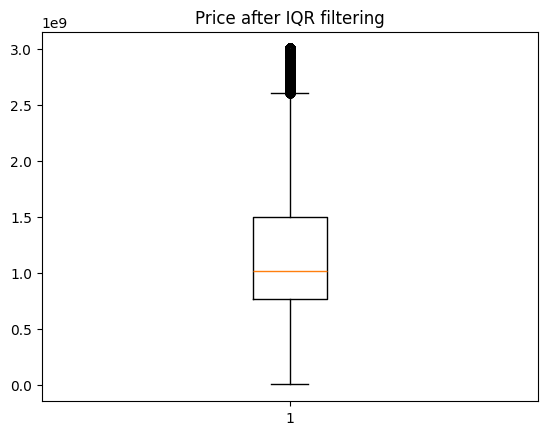

In [60]:
import matplotlib.pyplot as plt

plt.boxplot(df_clean['price'])
plt.title("Price after IQR filtering")
plt.show()

In [61]:
df_clean.isnull().sum().sort_values(ascending=False)

region               0
district             0
type_of_market       0
number_of_rooms      0
total_living_area    0
total_area           0
floor                0
total_floors         0
house_type           0
price                0
ceiling_height       0
kitchen_area         0
dtype: int64

In [62]:
df_clean['price'].describe()

count    3.981200e+04
mean     1.185609e+09
std      5.970306e+08
min      4.440481e+06
25%      7.668831e+08
50%      1.020110e+09
75%      1.500162e+09
max      3.000325e+09
Name: price, dtype: float64

In [63]:
df_clean.columns

Index(['region', 'district', 'type_of_market', 'number_of_rooms',
       'total_living_area', 'total_area', 'floor', 'total_floors',
       'house_type', 'price', 'ceiling_height', 'kitchen_area'],
      dtype='object')

In [64]:
df_clean.drop('region', axis=1, inplace=True)

In [65]:
df_clean.columns

Index(['district', 'type_of_market', 'number_of_rooms', 'total_living_area',
       'total_area', 'floor', 'total_floors', 'house_type', 'price',
       'ceiling_height', 'kitchen_area'],
      dtype='object')

In [66]:
df_clean['district_encoded'] = df_clean.groupby('district')['price'].transform('mean')
df_clean.drop('district', axis=1, inplace=True)

In [67]:
df_clean = pd.get_dummies(df_clean, columns=['house_type'], drop_first=True)

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_clean['type_of_market'] = le.fit_transform(df_clean['type_of_market'].astype(str))

In [69]:
y = df_clean['price']
X = df_clean.drop('price', axis=1)

In [70]:
print(X.shape)
print(X.columns)
print(X.head())

(39812, 13)
Index(['type_of_market', 'number_of_rooms', 'total_living_area', 'total_area',
       'floor', 'total_floors', 'ceiling_height', 'kitchen_area',
       'district_encoded', 'house_type_Деревянный', 'house_type_Кирпичный',
       'house_type_Монолитный', 'house_type_Панельный'],
      dtype='object')
   type_of_market  number_of_rooms  total_living_area total_area  floor  \
0               0                3               63.0         63      2   
1               1                1               58.0      34.30     14   
2               0                2               36.0         60      3   
3               0                4               80.0        108      1   
4               1                4               58.0        103      4   

   total_floors  ceiling_height  kitchen_area  district_encoded  \
0             4             3.0          10.0      9.248155e+08   
1            14             3.0          10.0      9.248155e+08   
2             4             3.0     

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
X_train.select_dtypes(include='object').columns

Index(['total_area'], dtype='object')

In [74]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = (
            X[col]
            .astype(str)
            .str.replace(' ', '')
        )
        X[col] = pd.to_numeric(X[col], errors='coerce')

In [75]:
X_train.select_dtypes(include='object').columns

Index(['total_area'], dtype='object')

In [76]:
# 1. clean string numbers
X = X.replace(r'\s+', '', regex=True)

# 2. convert to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# 3. fill NaN
X = X.fillna(X.median())

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [79]:
y_pred = model.predict(X_test)

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 302997978.04380774
RMSE: 423553675.77439153
R2: 0.5048505956363949


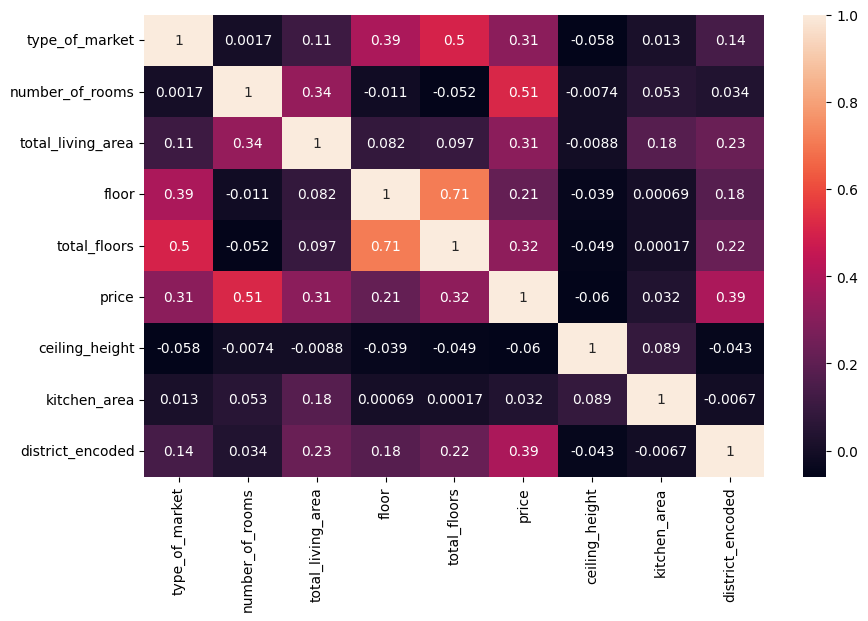

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_clean.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [82]:
from sklearn.preprocessing import StandardScaler

In [83]:
scaler = StandardScaler()

In [84]:
X_train_scaled = scaler.fit_transform(X_train)

In [85]:
X_test_scaled = scaler.transform(X_test)

In [86]:
import numpy as np

print(np.mean(X_train_scaled))
print(np.std(X_train_scaled))

2.927723626648659e-17
1.0


In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [88]:
model = LinearRegression()

In [89]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [90]:
y_pred = model.predict(X_test_scaled)

In [91]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 302997978.24787784
RMSE: 423553675.64422673
R2: 0.5048505959407295


In [92]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [93]:
y_pred = rf_model.predict(X_test)

In [94]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 139346075.03712627
RMSE: 252644751.46378356
R2: 0.823826772079971


<Axes: >

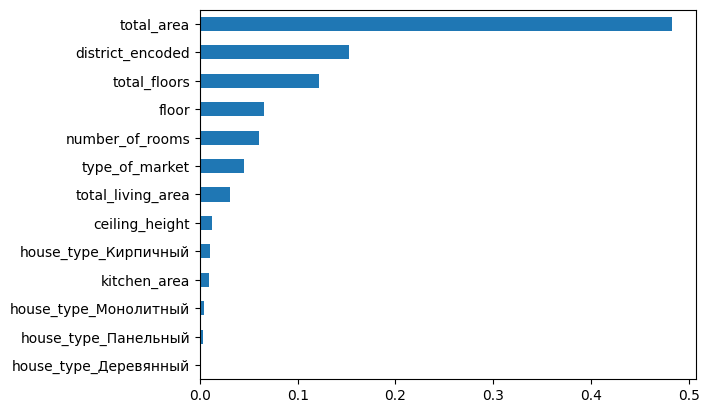

In [95]:
import pandas as pd

feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh')

In [96]:
import pickle

pickle.dump(rf_model, open("rf_model.pkl", "wb"))

In [97]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [98]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [99]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [100]:
y_pred = xgb.predict(X_test)

In [101]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 178351424.83536357
RMSE: 279345547.22581977
R2: 0.7846212475882097


In [102]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [104]:
df_clean.columns

Index(['type_of_market', 'number_of_rooms', 'total_living_area', 'total_area',
       'floor', 'total_floors', 'price', 'ceiling_height', 'kitchen_area',
       'district_encoded', 'house_type_Деревянный', 'house_type_Кирпичный',
       'house_type_Монолитный', 'house_type_Панельный'],
      dtype='object')

In [105]:
import pickle
model = pickle.load(open("rf_model.pkl", "rb"))
print(model.feature_names_in_)

['type_of_market' 'number_of_rooms' 'total_living_area' 'total_area'
 'floor' 'total_floors' 'ceiling_height' 'kitchen_area' 'district_encoded'
 'house_type_Деревянный' 'house_type_Кирпичный' 'house_type_Монолитный'
 'house_type_Панельный']
